In [15]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter

x_train = pd.read_csv('../../Dataset/X_train.csv')
y_train = pd.read_csv('../../Dataset/Y_train.csv')

x_train.head()

,Unnamed: 0,prdtypecode
0,0,10
1,1,2280
2,2,50
3,3,1280
4,4,2705


In [ ]:
y_train.head()

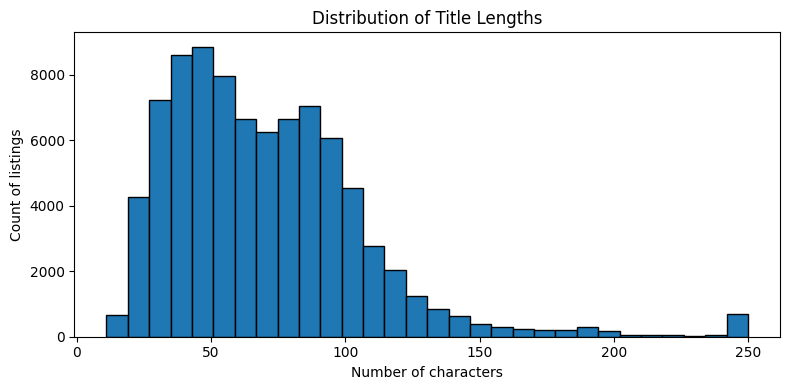

In [ ]:
# length of characters in designation/title
x_train['title_len'] = x_train['designation'].fillna('').str.len()

# plot
plt.figure(figsize=(8,4))
plt.hist(x_train['title_len'], bins=30, edgecolor='black')
plt.title('Distribution of Title Lengths')
plt.xlabel('Number of characters')
plt.ylabel('Count of listings')
plt.tight_layout()
plt.show()

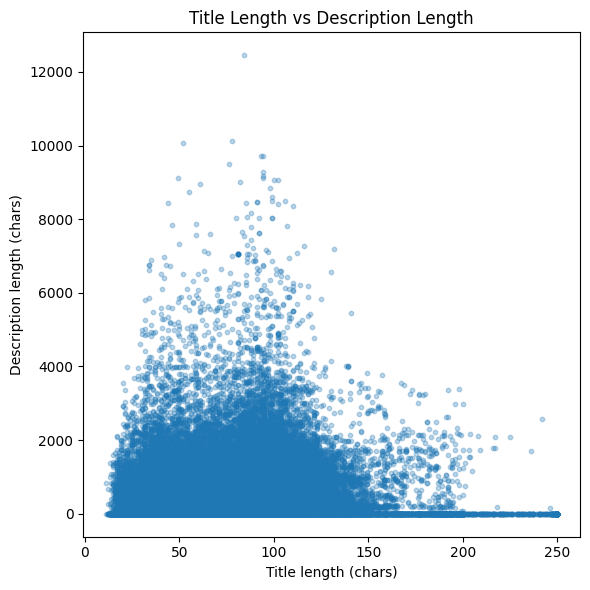

In [6]:
# compute lengths
x_train['title_len'] = x_train['designation'].fillna('').str.len()
x_train['desc_len']  = x_train['description'].fillna('').str.len()

# scatter
plt.figure(figsize=(6,6))
plt.scatter(x_train['title_len'], x_train['desc_len'], alpha=0.3, s=10)
plt.title('Title Length vs Description Length')
plt.xlabel('Title length (chars)')
plt.ylabel('Description length (chars)')
plt.tight_layout()
plt.show()

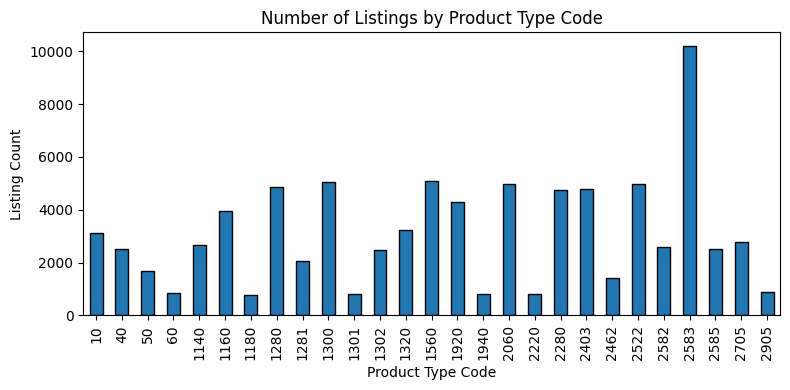

In [9]:
counts = x_train.merge(y_train, left_index=True, right_index=True)['prdtypecode'].value_counts().sort_index()

plt.figure(figsize=(8,4))
counts.plot(kind='bar', edgecolor='black')
plt.title('Number of Listings by Product Type Code')
plt.xlabel('Product Type Code')
plt.ylabel('Listing Count')
plt.tight_layout()
plt.show()

In [19]:
df = x_train.copy()
df['prdtypecode'] = y_train['prdtypecode'].fillna('')

# Most‐common product type code
counts = df['prdtypecode'].value_counts()
top_code = counts.idxmax()
print(f"Most listings are in product type code {top_code} ({counts[top_code]} listings)\n")


Most listings are in product type code 2583 (10209 listings)



In [26]:
# This creates a smaller DataFrame subset containing only rows where the prdtypecode matches the one we identified.
subset = df[df['prdtypecode'] == top_code]

print("Number of rows in subset:", len(subset))
subset.head()

Number of rows in subset: 10209


,Unnamed: 0,designation,description,productid,imageid,prdtypecode
20,20,Kit de désinfection pour piscines enfants 20990,NaN,3936362802,1268740880,2583
39,39,Bouée gonflable River tube - OOGARDEN,Bouée gonflable River tube en PVC idéale pour ...,3147314797,1225887302,2583
53,53,Testeur électronique de pH,Utilisation du Testeur électronique de pHGrâce...,207151480,941622055,2583
58,58,Pompe de filtration Speck Badu 95,NaN,4128438373,1295960377,2583
64,64,AstralCom 1 CV Mono de DAB - Surpresseur piscine,Tension (V) : Monophasé - 230 V Puissance : 1...,1857269337,1105831362,2583


In [47]:
# Module for accumulating counts (in library "Collections")
word_counts = Counter()
for title in subset['designation'].dropna().str.lower():
    # Extracts all “word” tokens (any sequence of alphanumeric characters)
    tokens = re.findall(r'\w+', title)
    # Incrementing the count for each word
    word_counts.update(tokens)

print("Number of words:", len(word_counts))
word_counts.most_common(10)

Number of words: 7545


[('piscine', 4674),
 ('de', 3913),
 ('x', 3421),
 ('pour', 2139),
 ('kit', 1932),
 ('à', 1927),
 ('m', 1748),
 ('bâche', 1499),
 ('spa', 1130),
 ('cm', 1099)]

In [28]:
# Show top 5 words
top5 = word_counts.most_common(5)
print("Top 5 words in titles for this product type:")
for w, freq in top5:
    print(f"  {w}: {freq}")


Top 5 words in titles for this product type:
  piscine: 4674
  de: 3913
  x: 3421
  pour: 2139
  kit: 1932


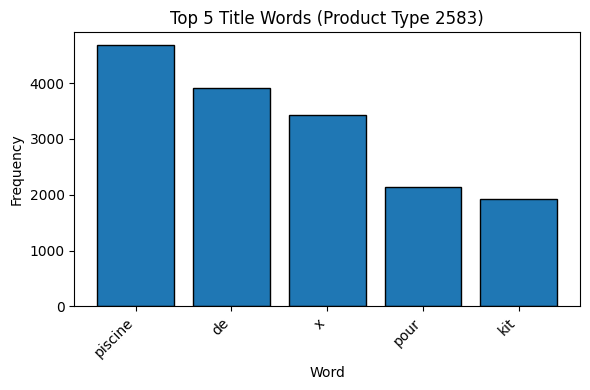

In [29]:
# Bar chart of those words
labels, freqs = zip(*top5)
plt.figure(figsize=(6,4))
plt.bar(labels, freqs, edgecolor='black')
plt.title(f"Top 5 Title Words (Product Type {top_code})")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()